## Install libraries (optional)

In [1]:
#!pip install -q cartopy

## Import required libraries and read the data

In [1]:
import pandas as pd
import geopandas as gpd

df_perceived = pd.read_csv(r'../../datafiles/processed/flood_table_v2.csv')
gdf_perceived = gpd.read_file(r'../../shapefiles/Emily_shapefile/district_shapefile.shp').to_crs(epsg=4326)

# 1. Reformat Shapefile (Section 3.0 in your R code)
# Rename columns to match your desired output names
gdf_district = gdf_perceived[['state23', 'st_code', 'GeoName', 'GEOID', 'di_code', 'geometry', 'population']].copy()
gdf_district = gdf_district.rename(columns={'GeoName': 'ShapeName', 'GEOID': 'GeoID'})
gdf_district['GeoID'] = pd.to_numeric(
    gdf_district['GeoID'].str.lstrip('x'), 
    errors='coerce'
)

df_perceived['GeoID'] = df_perceived['GeoID'].astype(int)

# 3. Merge Data
shape_merge = gdf_district.merge(df_perceived, on='GeoID', how='outer')

# Clean up: remove the temporary key and the redundant GeoName column from the CSV side
perceived_data = shape_merge[['geometry', 'state23', 'st_code', 'GeoID', 'GeoName', 'population', 'pred_per']].copy()
perceived_data = perceived_data.rename(columns={'pred_per': 'perceived'})

print(perceived_data.shape)
perceived_data

(735, 7)


,geometry,state23,st_code,GeoID,GeoName,population,perceived
0,"MULTIPOLYGON (((93.95032 6.93412, 93.95018 6.9...",ANDAMAN & NICOBAR,35,35603.0,"Andaman & Nicobar, Nicobar",26697.0,49.083213
1,"MULTIPOLYGON (((92.79855 12.07663, 92.79868 12...",ANDAMAN & NICOBAR,35,35632.0,"Andaman & Nicobar, North & Middle Andaman",71857.0,41.220610
2,"MULTIPOLYGON (((92.51836 10.90084, 92.51906 10...",ANDAMAN & NICOBAR,35,35602.0,"Andaman & Nicobar, South Andaman",169248.0,75.111021
3,"POLYGON ((77.13122 15.42632, 77.13199 15.42411...",ANDHRA PRADESH,28,28502.0,"Andhra Pradesh, Anantapur",2757734.0,41.240960
4,"MULTIPOLYGON (((78.65631 13.90609, 78.65625 13...",ANDHRA PRADESH,28,28503.0,"Andhra Pradesh, Chittoor",2864035.0,45.562078
...,...,...,...,...,...,...,...
730,"POLYGON ((88.01265 23.8395, 88.0135 23.83846, ...",WEST BENGAL,19,19306.0,"West Bengal, Purba Barddhaman",5321647.0,53.790501
731,"MULTIPOLYGON (((87.98908 22.2382, 87.98649 22....",WEST BENGAL,19,19317.0,"West Bengal, Purba Medinipur",3422612.0,81.184847
732,"POLYGON ((86.8204 23.68782, 86.82294 23.68642,...",WEST BENGAL,19,19321.0,"West Bengal, Puruliya",1851557.0,51.733313
733,"MULTIPOLYGON (((88.01734 21.56009, 88.01743 21...",WEST BENGAL,19,19304.0,"West Bengal, South Twenty-Four Parganas",5315644.0,64.109090


## Join assessed risk information

In [2]:
import geopandas as gpd

imd_gdf = gpd.read_file(r'../../datafiles/external/IMD_FloodCount_1969-2019.geojson').to_crs(epsg=3857)
imd_gdf['geometry'] = imd_gdf['geometry'].centroid
imd_gdf = imd_gdf.to_crs(perceived_data.crs)

# Spatial join transferring only the flood count column
joined_gdf = gpd.sjoin(
    perceived_data, 
    imd_gdf[['Number of_Flood Events', 'geometry']], 
    how='left', 
    predicate='intersects'
).drop(columns=['index_right'])

# Optional: fill districts with no match as 0
joined_gdf['Number of_Flood Events'] = joined_gdf['Number of_Flood Events'].fillna(0)
perceived_data['imd_flood_count'] = perceived_data.merge(joined_gdf, on='GeoID', how='outer')['Number of_Flood Events']

# Apply the mapping to a new column
gdf = perceived_data.copy()
gdf['assessed'] = gdf['imd_flood_count'].clip(upper=gdf['imd_flood_count'].quantile(0.95))
gdf['assessed'] = 100 * gdf['assessed'] / gdf['assessed'].max()
gdf['gap'] = gdf['assessed'] - gdf['perceived']

print(gdf.shape)
gdf.head()

(735, 10)


,geometry,state23,st_code,GeoID,GeoName,population,perceived,imd_flood_count,assessed,gap
0,"MULTIPOLYGON (((93.95032 6.93412, 93.95018 6.9...",ANDAMAN & NICOBAR,35,35603.0,"Andaman & Nicobar, Nicobar",26697.0,49.083213,0.0,0.000000,-49.083213
1,"MULTIPOLYGON (((92.79855 12.07663, 92.79868 12...",ANDAMAN & NICOBAR,35,35632.0,"Andaman & Nicobar, North & Middle Andaman",71857.0,41.220610,1.0,1.587302,-39.633308
2,"MULTIPOLYGON (((92.51836 10.90084, 92.51906 10...",ANDAMAN & NICOBAR,35,35602.0,"Andaman & Nicobar, South Andaman",169248.0,75.111021,1.0,1.587302,-73.523719
3,"POLYGON ((77.13122 15.42632, 77.13199 15.42411...",ANDHRA PRADESH,28,28502.0,"Andhra Pradesh, Anantapur",2757734.0,41.240960,30.0,47.619048,6.378088
4,"MULTIPOLYGON (((78.65631 13.90609, 78.65625 13...",ANDHRA PRADESH,28,28503.0,"Andhra Pradesh, Chittoor",2864035.0,45.562078,35.0,55.555556,9.993478


In [3]:
gdf['imd_flood_count'].quantile([0.5, 0.9, 0.95, 0.98])

0.50    20.00
0.90    49.60
0.95    63.00
0.98    85.56
Name: imd_flood_count, dtype: float64

In [4]:
correlation = gdf['assessed'].corr(gdf['perceived'])
print(f"Correlation coefficient: {correlation:.2f}")

Correlation coefficient: 0.14


In [5]:
(gdf['gap'] > 15).value_counts()

gap
False    667
True      68
Name: count, dtype: int64

In [6]:
100 * (gdf['gap'] > 15).value_counts() / gdf.shape[0]

gap
False    90.748299
True      9.251701
Name: count, dtype: float64

In [7]:
gdf[['perceived', 'assessed']].describe()

,perceived,assessed
count,729.000000,735.000000
mean,61.641867,35.782313
std,14.545307,28.384382
min,24.559632,0.000000
25%,52.182894,13.492063
50%,61.896355,31.746032
75%,72.367206,52.380952
max,89.426382,100.000000


## Aggregated the data to state level

In [ ]:
%%time

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from shapely.geometry import Polygon, MultiPolygon

# 1. Define a helper to handle the mode (takes the first result if there is a tie)
def get_mode(x):
    return x.mode().iloc[0] if not x.mode().empty else None

# 2. Dissolve the districts into states
# We group by 'state' and apply 'get_mode' to the 'floodrisk' column
gdf_state = gdf.dissolve(
    by='state23',
    aggfunc={'assessed': np.mean, 'perceived': np.mean}
)

# 3. Check the result
# 'state' is now the index, and the geometry is the combined state shape
gdf_state.reset_index(inplace=True)
gdf_state.set_crs("EPSG:4326", allow_override=True, inplace=True)

# delete holes
def remove_holes(geometry):
    if geometry.geom_type == 'Polygon':
        return Polygon(geometry.exterior)
    elif geometry.geom_type == 'MultiPolygon':
        # Reconstruct each part of the MultiPolygon without holes
        return MultiPolygon([Polygon(p.exterior) for p in geometry.geoms])
    return geometry
gdf_state.geometry = gdf_state.geometry.apply(remove_holes)

gdf_state['gap'] =  gdf_state['assessed'] - gdf_state['perceived']

gdf_state.head()

In [ ]:
gdf.to_file(r'../../datafiles/processed/260514_India_DistrictGap_v1.gpkg')
gdf_state.to_file(r'../../datafiles/processed/260514_India_StateGap_v1.gpkg')

,imd_flood_count,assessed,perceived,gap
count,735.000000,735.000000,729.000000,729.000000
mean,23.623129,35.782313,61.641867,-25.739239
std,21.204230,28.384382,14.545307,30.032906
min,0.000000,0.000000,24.559632,-87.673444
25%,8.500000,13.492063,52.182894,-48.556739
50%,20.000000,31.746032,61.896355,-28.114860
75%,33.000000,52.380952,72.367206,-8.214868
max,127.000000,100.000000,89.426382,71.885913


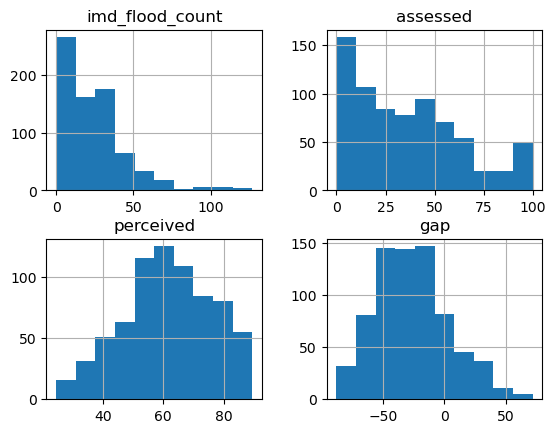

In [10]:
display(gdf[['imd_flood_count', 'assessed', 'perceived', 'gap']].describe())
_ = gdf[['imd_flood_count', 'assessed', 'perceived', 'gap']].hist()

<Axes: >

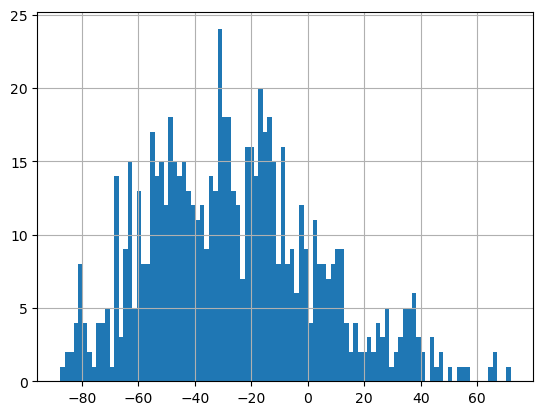

In [11]:
gdf['gap'].hist(bins=100)

<Axes: >

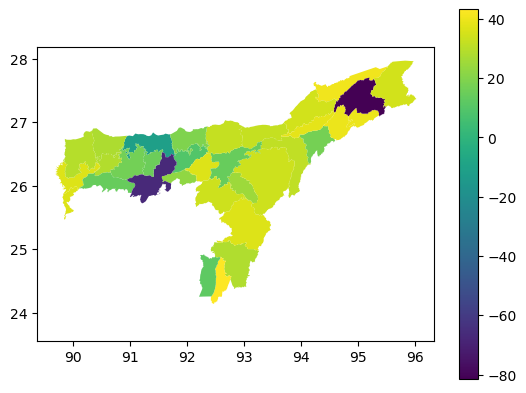

In [12]:
gdf.loc[gdf['state23'] == 'ASSAM'].plot('gap', legend=True)

## Plot the maps

<timed exec>:150: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.


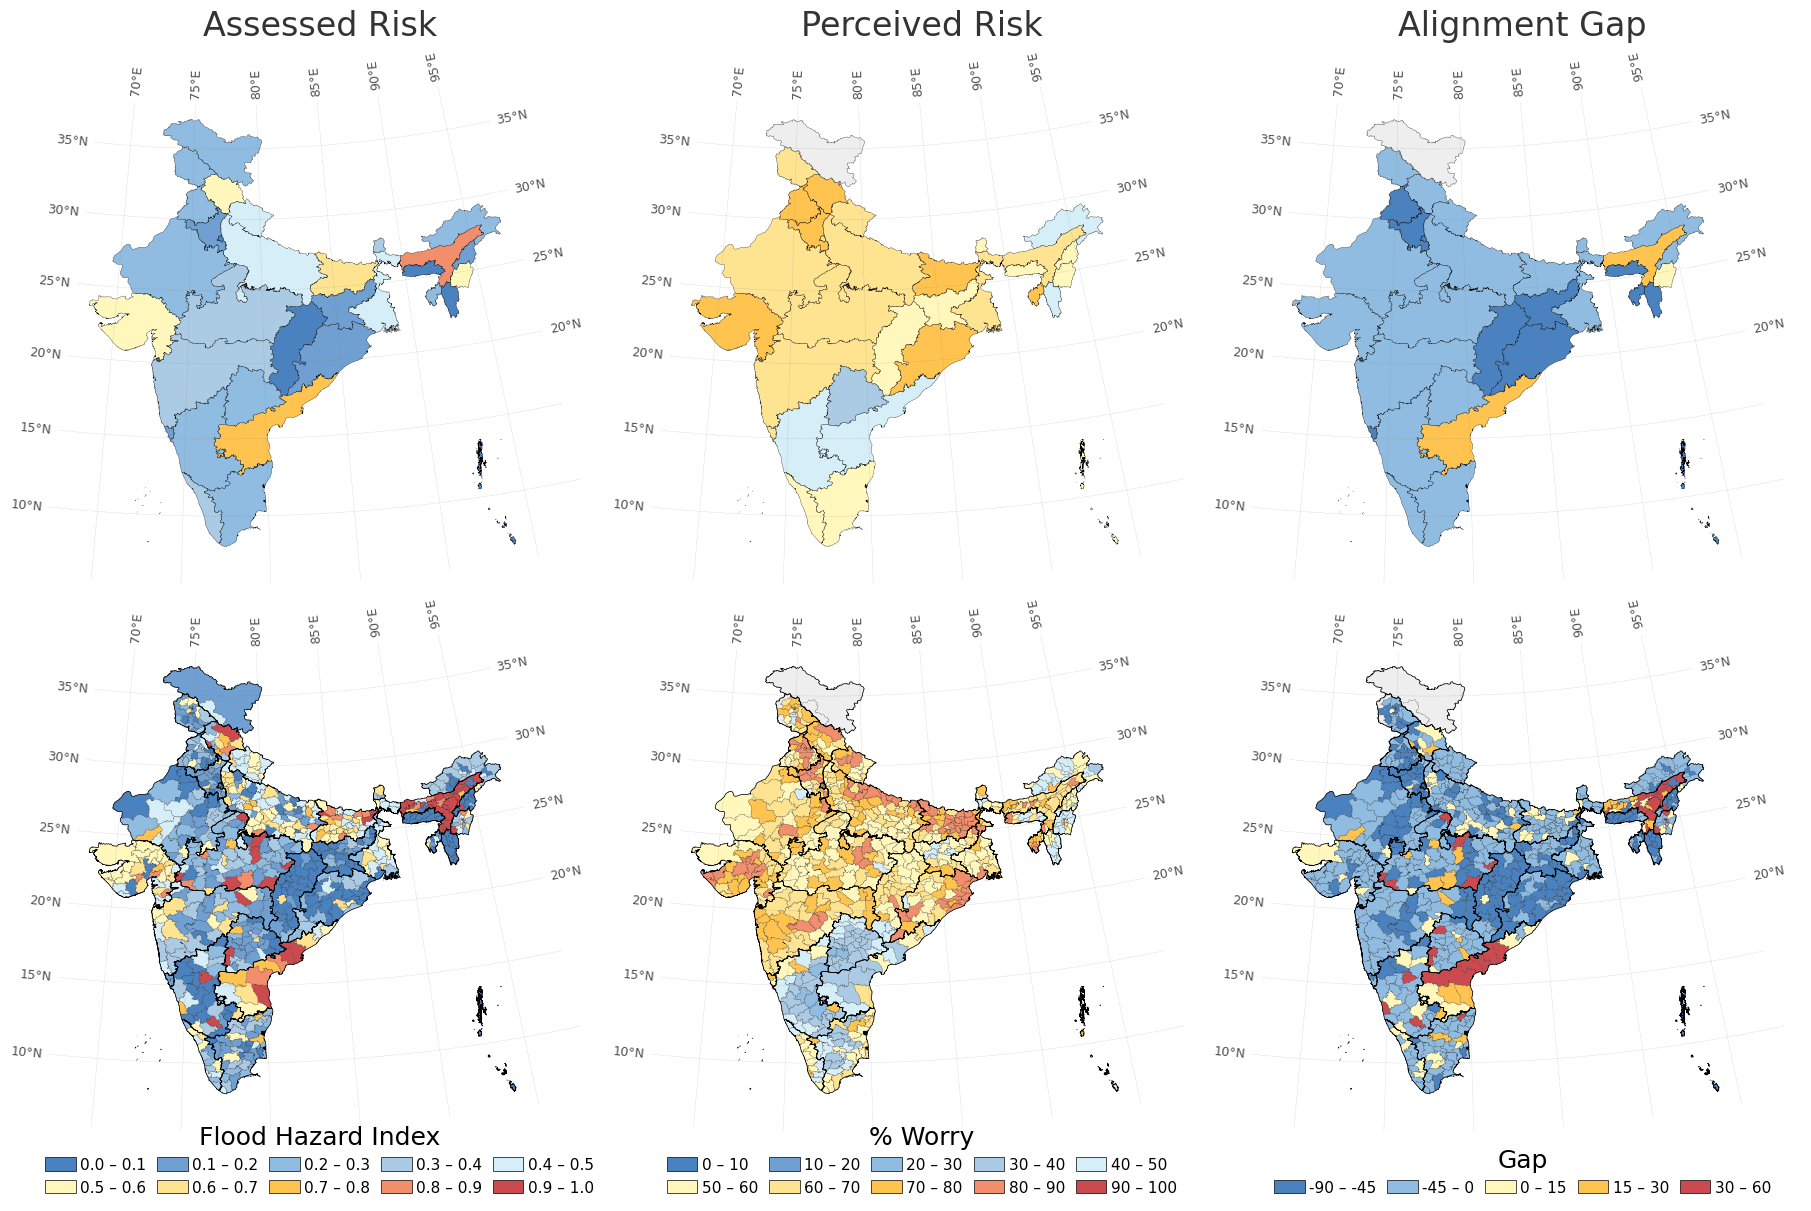

CPU times: total: 20min 29s
Wall time: 21min 19s


In [43]:
%%time

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# --- 1. GLOBAL SETTINGS & PROJECTION ---
STRAIGHT_LON = 77.5
PROJ = ccrs.LambertConformal(central_longitude=STRAIGHT_LON, central_latitude=23.0)
DATA_CRS = ccrs.PlateCarree()
BOUNDS = gdf.total_bounds
PAD = 1.0

n = 100
lons = np.r_[np.linspace(BOUNDS[0]-PAD, BOUNDS[2]+PAD, n), np.full(n, BOUNDS[2]+PAD),
             np.linspace(BOUNDS[2]+PAD, BOUNDS[0]-PAD, n), np.full(n, BOUNDS[0]-PAD)]
lats = np.r_[np.full(n, BOUNDS[1]-PAD), np.linspace(BOUNDS[1]-PAD, BOUNDS[3]+PAD, n),
             np.full(n, BOUNDS[3]+PAD), np.linspace(BOUNDS[3]+PAD, BOUNDS[1]-PAD, n)]
AOI_PATH = mpath.Path(np.column_stack([lons, lats]))

# Had made assessed column go from 0 to 100 to share with others so scaling it back to 0-1 
if gdf_state['assessed'].max() > 1:
    gdf_state['assessed'] = gdf_state['assessed'] / gdf_state['assessed'].max()
if gdf['assessed'].max() > 1:
    gdf['assessed'] = gdf['assessed'] / gdf['assessed'].max()

# --- 2. COLORS AND CATEGORIZATION LOGIC ---
# Full 10-color palette (Softened)
ordered_colors_10 = [
    '#4a81bf', '#6fa0d1', '#8fbce0', '#abcbe4', '#d6eef8', 
    '#fff7bc', '#fee391', '#fec44f', '#f28e6c', '#cb4a4f'
]
# Diverging 5-color palette for the Gap (Deep Blue, Light Blue, Yellow, Orange, Deep Red)
ordered_colors_5 = [ordered_colors_10[0], ordered_colors_10[2], ordered_colors_10[5], ordered_colors_10[7], ordered_colors_10[9]]

custom_cmap_10 = ListedColormap(ordered_colors_10)
custom_cmap_5 = ListedColormap(ordered_colors_5)

def prepare_categorical_data(df, column_name, bins, colors):
    labels = [f"{bins[i]} – {bins[i+1]}" for i in range(len(bins)-1)]
    cat_col = f"{column_name}_cat"
    # Clip to handle values outside the specific range (e.g., < -10 or > 90)
    clipped_series = df[column_name].clip(lower=bins[0], upper=bins[-1])
    df[cat_col] = pd.cut(clipped_series, bins=bins, labels=labels, include_lowest=True)
    df[cat_col] = df[cat_col].cat.set_categories(labels)
    
    num_classes = len(colors)
    elements = [Patch(facecolor=colors[i], edgecolor='black', label=labels[i], linewidth=0.5) for i in range(num_classes)]
    
    # Reorder only for 10-class (2 rows), keep 5-class in original order (1 row)
    if num_classes == 10:
        reordered_elements = [elements[i] for i in [0, 5, 1, 6, 2, 7, 3, 8, 4, 9]]
    else:
        reordered_elements = elements
    return cat_col, reordered_elements

# Bins defined as per your requirements
bins1 = [round(x, 1) for x in np.linspace(0, 1, 11)]    # 0-1
bins2 = [int(x) for x in np.linspace(0, 100, 11)]       # 0-100
bins3 = [-90, -45, 0, 15, 30, 60]                       # -10 to 90 (Gap)

# Apply categorization
cat_assessed, handles1 = prepare_categorical_data(gdf, 'assessed', bins1, ordered_colors_10)
prepare_categorical_data(gdf_state, 'assessed', bins1, ordered_colors_10)

cat_perceived, handles2 = prepare_categorical_data(gdf, 'perceived', bins2, ordered_colors_10)
prepare_categorical_data(gdf_state, 'perceived', bins2, ordered_colors_10)

cat_gap, handles3 = prepare_categorical_data(gdf, 'gap', bins3, ordered_colors_5)
prepare_categorical_data(gdf_state, 'gap', bins3, ordered_colors_5)

# --- 3. FORMATTING FUNCTION ---
def format_india_map(ax, title, is_left_col=False, is_top_row=False):
    ax.set_boundary(AOI_PATH, transform=DATA_CRS)
    ax.set_extent([BOUNDS[0]-PAD, BOUNDS[2]+PAD, BOUNDS[1]-PAD, BOUNDS[3]+PAD], crs=DATA_CRS)
    ax.spines['geo'].set_visible(False)
    
    gl = ax.gridlines(
        draw_labels=True, linewidth=0.3, color='gray', alpha=0.4, linestyle='--',
        x_inline=False, y_inline=False
    )    
    gl.top_labels = True      # Enable top
    gl.left_labels = True     # Enable left
    gl.right_labels = False    # Turn off right
    gl.bottom_labels = False   # Turn off bottom (cleans up the middle of the grid)
    gl.padding = 10
    gl.xlabel_style = {'size': 9, 'color': '#4F4F4F'}
    gl.ylabel_style = {'size': 9, 'color': '#4F4F4F'}
    ax.set_title(title, fontsize=24, pad=10, color='#333333')
    ax.set_aspect('auto')

def safe_plot(df, ax, col, cmap, lw):
    if not df[col].isna().all():
        df.plot(ax=ax, column=col, cmap=cmap, transform=DATA_CRS, edgecolor='black', linewidth=lw, missing_kwds={'color': '#eeeeee'})
    else:
        df.plot(ax=ax, transform=DATA_CRS, facecolor='#f2f2f2', edgecolor='black', linewidth=lw)

# --- 4. CREATE THE FIGURE (FIXED ASPECT RATIO) ---
# Removed constrained_layout=True to prevent legend-driven squeezing
fig, axs = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={'projection': PROJ}, constrained_layout=True)
(ax1, ax2, ax3), (ax4, ax5, ax6) = axs

# Added aspect='equal' to all plot calls to force correct geographic shape
def safe_plot(df, ax, col, cmap, lw):
    if not df[col].isna().all():
        df.plot(ax=ax, column=col, cmap=cmap, transform=DATA_CRS, 
                edgecolor='black', linewidth=lw, aspect='equal', # Added aspect='equal'
                missing_kwds={'color': '#eeeeee'})
    else:
        df.plot(ax=ax, transform=DATA_CRS, facecolor='#eeeeee', 
                edgecolor='black', linewidth=lw, aspect='equal')

# Assessed Risk
format_india_map(ax1, "Assessed Risk", is_left_col=True, is_top_row=True)
safe_plot(gdf_state, ax1, 'assessed_cat', custom_cmap_10, 0.2)
format_india_map(ax4, "", is_left_col=True, is_top_row=False) 
safe_plot(gdf, ax4, 'assessed_cat', custom_cmap_10, 0.1)

# Perceived Risk
format_india_map(ax2, "Perceived Risk", is_left_col=False, is_top_row=True)
safe_plot(gdf_state, ax2, 'perceived_cat', custom_cmap_10, 0.2)
format_india_map(ax5, "", is_left_col=False, is_top_row=False)
safe_plot(gdf, ax5, 'perceived_cat', custom_cmap_10, 0.1)

# Alignment Gap
format_india_map(ax3, "Alignment Gap", is_left_col=False, is_top_row=True)
safe_plot(gdf_state, ax3, 'gap_cat', custom_cmap_5, 0.2)
format_india_map(ax6, "", is_left_col=False, is_top_row=False)
safe_plot(gdf, ax6, 'gap_cat', custom_cmap_5, 0.1)

for ax in [ax4, ax5, ax6]:
    gdf_state.boundary.plot(ax=ax, transform=DATA_CRS, color='black', linewidth=0.5, aspect='equal')

for ax in axs.flat:
    ax.set_aspect('auto')
    
# --- 5. LEGEND PLACEMENT & SPACING ---
legend_kwds = {'loc': 'lower center', 'frameon': False, 'handleheight': 1.0, 
               'handlelength': 2, 'handletextpad': 0.3, 'columnspacing': 0.7, 
               'title_fontsize': 18, 'prop': {'size': 11}}

# Shifted legends slightly lower to avoid crowding the map
ax4.legend(handles=handles1, bbox_to_anchor=(0.5, -0.175), title="Flood Hazard Index", ncol=5, **legend_kwds)
ax5.legend(handles=handles2, bbox_to_anchor=(0.5, -0.175), title="% Worry", ncol=5, **legend_kwds)
ax6.legend(handles=handles3, bbox_to_anchor=(0.5, -0.175), title="Gap", ncol=5, **legend_kwds)

# Manual adjustment of spacing since constrained_layout is off
plt.subplots_adjust(wspace=0.1, hspace=0.05)

plt.savefig('../../output/assessed_perceived_risk.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 2: alignment gap - grayed out map

<timed exec>:54: UserWarning: The figure layout has changed to tight


CPU times: total: 6min 27s
Wall time: 6min 41s


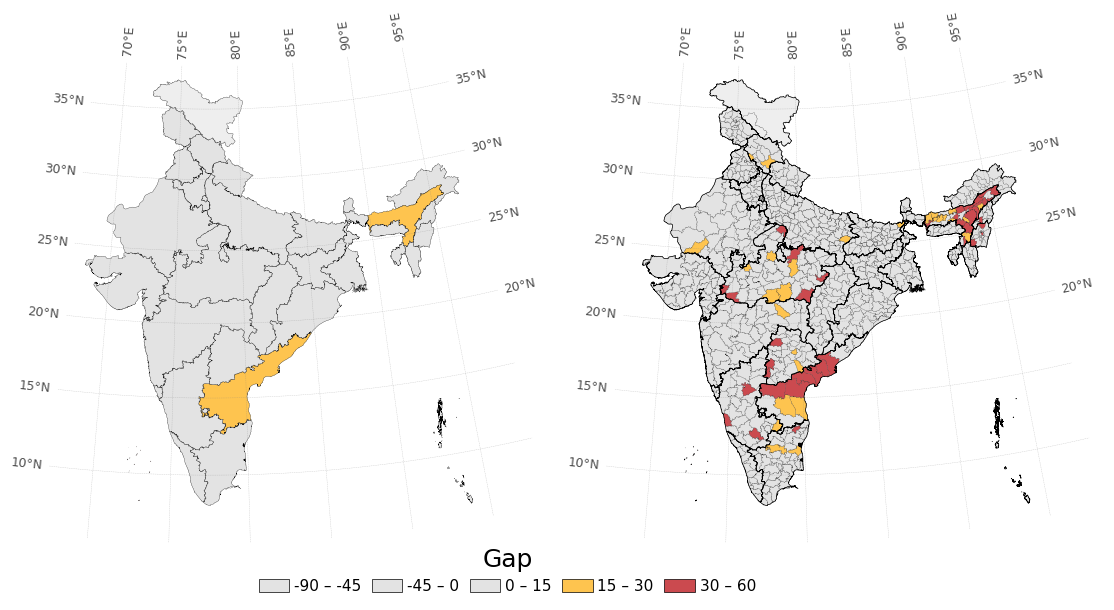

In [14]:
%%time

# --- 1. DEFINE SPECIAL COLORS FOR THE GAP ---
# Classes 1-3: Gray shades | Classes 4-5: Orange and Red highlights
ordered_colors_gap = [
    '#e3e3e3', # -10 to 10 (Lightest Gray)
    '#e3e3e3', # 10 to 30  (Medium Gray)
    '#e3e3e3', # 30 to 50  (Dark Gray)
    '#fec44f', # 50 to 70  (Orange)'#fec44f', '#f28e6c', '#cb4a4f'
    '#cb4a4f'  # 70 to 90  (Red)
]
custom_cmap_gap = ListedColormap(ordered_colors_gap)

# --- 2. PREPARE CATEGORICAL DATA ---
# Ensure bins3 matches the 5-class logic requested: -10 to 90
bins3 = [-90, -45, 0, 15, 30, 60]

# Prepare handles specifically for this 5-class gray-to-red scheme
cat_gap, handles_gap = prepare_categorical_data(gdf, 'gap', bins3, ordered_colors_gap)
_ = prepare_categorical_data(gdf_state, 'gap', bins3, ordered_colors_gap)

# --- 3. PLOTTING ---
fig, axs = plt.subplots(1, 2, figsize=(14, 10), subplot_kw={'projection': PROJ}, layout="constrained")
ax3, ax6 = axs

# Left Map: State Level Alignment Gap
format_india_map(ax3, "", is_left_col=True, is_top_row=True)
safe_plot(gdf_state, ax3, 'gap_cat', custom_cmap_gap, 0.2)

# Right Map: National Level Alignment Gap
format_india_map(ax6, "", is_left_col=False, is_top_row=True)
safe_plot(gdf, ax6, 'gap_cat', custom_cmap_gap, 0.1)

# Add State Boundaries to the National map for context
gdf_state.boundary.plot(ax=ax6, transform=DATA_CRS, color='black', linewidth=0.5, aspect='equal')

# Force correct geographic shape
for ax in axs:
    ax.set_aspect('equal')

# --- 4. LEGEND PLACEMENT ---
legend_kwds = {'loc': 'lower center', 'frameon': False, 'handleheight': 1.0, 
               'handlelength': 2, 'handletextpad': 0.3, 'columnspacing': 0.7, 
               'title_fontsize': 18, 'prop': {'size': 11}}

# Centering the legend under the entire 1x2 panel
# We anchor it to the figure or relative to the second axis
ax6.legend(
    handles=handles_gap, 
    bbox_to_anchor=(-0.18, -0.15), # Adjusted to center between the two maps
    title="Gap", 
    ncol=5, 
    **legend_kwds
)

plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
plt.savefig('../../output/grayed_out_map.png', dpi=300, bbox_inches='tight')

# Figure 3: Scatterplot

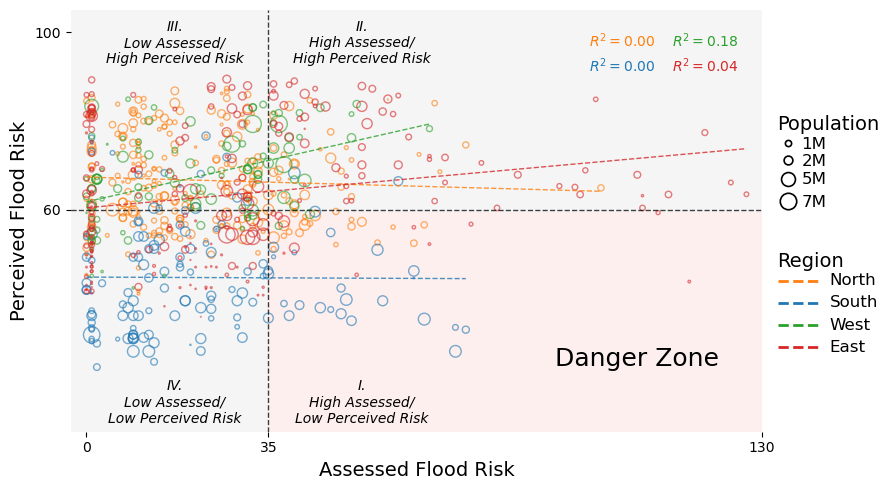

CPU times: total: 531 ms
Wall time: 598 ms


In [29]:
%%time

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Handle NaNs: Create a temporary DataFrame without missing values
clean_df = gdf[['imd_flood_count', 'perceived', 'state23', 'population']].dropna()

# Define the mapping dictionary
zone_map = {
    'PUNJAB': 'North', 'HARYANA': 'North', 'HIMACHAL PRADESH': 'North', 
    'UTTARAKHAND': 'North', 'UTTAR PRADESH': 'North', 'DELHI': 'North', 
    'CHANDIGARH': 'North', 'JAMMU & KASHMIR': 'North', 'LADAKH': 'North',
    'RAJASTHAN': 'North', 'MADHYA PRADESH': 'North',
    'KERALA': 'South', 'TAMIL NADU': 'South', 'KARNATAKA': 'South', 
    'ANDHRA PRADESH': 'South', 'TELANGANA': 'South', 'PUDUCHERRY': 'South', 
    'LAKSHADWEEP': 'South', 'ANDAMAN & NICOBAR': 'South',
    'GUJARAT': 'West', 'MAHARASHTRA': 'West', 'GOA': 'West', 
    'CHHATTISGARH': 'West', 'DADRA & NAGAR HAVELI & DAMAN & DIU': 'West',
    'WEST BENGAL': 'East', 'ODISHA': 'East', 'BIHAR': 'East', 
    'JHARKHAND': 'East', 'ASSAM': 'East', 'SIKKIM': 'East', 
    'ARUNACHAL PRADESH': 'East', 'NAGALAND': 'East', 'MANIPUR': 'East', 
    'MIZORAM': 'East', 'TRIPURA': 'East', 'MEGHALAYA': 'East'
}

clean_df['zone'] = clean_df['state23'].map(zone_map)

# Define color palette
colors = {
    'North': '#ff7f0e',
    'South': '#1f77b4', 
    'West': '#2ca02c',  
    'East': '#d62728'   
}

fig, ax = plt.subplots(1, 1, figsize=(9, 5))

# --- DANGER ZONE BACKGROUND (red color) ---
# High Assessed (>30) but Low Perceived (<60)
ax.axvspan(35, 130, ymin=0, ymax=60/(105+10), color='#feefef', alpha=1, zorder=0)

# --- LOOP THROUGH ZONES ---
x_start = 0.75  # First column X
y_start = 0.95  # Starting Y

for i, (zone, color) in enumerate(colors.items()):
    subset = clean_df[clean_df['zone'] == zone]
    
    if len(subset) > 1:
        zx = subset['imd_flood_count']
        zy = subset['perceived']
        
        slope, intercept, r_value, p_value, std_err = stats.linregress(zx, zy)
        r_sq = r_value**2
        
        # Plot Scatter
        ax.scatter(zx, zy, alpha=0.6, facecolors='none', edgecolors=color, 
                   s=subset['population'] / 50000, linewidth=1)
        
        # Plot Line
        line_x = np.array([zx.min(), zx.max()])
        ax.plot(line_x, slope * line_x + intercept, color=color, 
                linestyle='--', linewidth=1, alpha=0.8)
        
        # COLUMN LOGIC
        # Column 1 for first two items, Column 2 for the rest
        col_x = x_start if i < 2 else x_start + 0.12
        # Reset y_pos for the second column
        row_y = y_start if i % 2 == 0 else y_start - 0.06
        
        # Add BOLD colored R2 text
        ax.text(col_x, row_y, f'$R^2={r_sq:.2f}$', transform=ax.transAxes, 
                fontsize=10, color=color, fontweight='bold', verticalalignment='top')

# --- AESTHETICS ---
# POPULATION SIZE BUBBLE
# 1. Define the representative population values you want in the legend
# Adjust these based on your specific data range
legend_x = 135
legend_y_start = 75

legend_sizes = [1_000_000, 2_000_000, 5_000_000, 7_000_000]
labels = ["1M", "2M", "5M", "7M"]

ax.text(legend_x-2, legend_y_start + 3, "Population", ha='left', 
        fontsize=14, color='black').set_clip_on(False)

y_pos = legend_y_start
y_pos_multiplier = [0.8, 0.7, 0.6]
for j, (size, label) in enumerate(zip(legend_sizes, labels)):
    radius = np.sqrt(size / 50000) / 2
    
    ax.plot(legend_x, y_pos, marker='o', markersize=np.sqrt(size / 50000),
            markerfacecolor='none', markeredgecolor='black', 
            markeredgewidth=1.2, linestyle='none',
            clip_on=False)
    
    ax.text(legend_x + 5, y_pos-0.25, label, va='center', ha='center', 
            fontsize=12, color='black').set_clip_on(False)

    if j + 1 < len(legend_sizes):
        next_radius = np.sqrt(legend_sizes[j + 1] / 50000) / 2
        padding = 2
        y_pos -= (radius * y_pos_multiplier[j] + padding)


# --- REGION LEGEND ---
region_y_start = y_pos - 15  # gap below the last population bubble

ax.text(legend_x - 2, region_y_start, "Region", ha='left',
        fontsize=14, color='black').set_clip_on(False)

region_y = region_y_start - 3
for zone, color in colors.items():
    ax.plot([legend_x - 2, legend_x + 6], [region_y, region_y],
            color=color, linewidth=2, linestyle='--',
            clip_on=False)
    ax.text(legend_x + 8, region_y, zone, va='center', ha='left',
            fontsize=12, color='black').set_clip_on(False)
    region_y -= 5
        
# Add reference lines
ax.axvline(x=35, color='black', linestyle='--', linewidth=1, alpha=0.75)
ax.axhline(y=60, color='black', linestyle='--', linewidth=1, alpha=0.75)

ax.text(53, 12, 'I.\nHigh Assessed/\nLow Perceived Risk', color='black', fontsize=10, ha='center', style='italic')
ax.text(53, 93, 'II.\nHigh Assessed/\nHigh Perceived Risk', color='black', fontsize=10, ha='center', style='italic')
ax.text(17, 93, 'III.\nLow Assessed/\nHigh Perceived Risk', color='black', fontsize=10, ha='center', style='italic')
ax.text(17, 12, 'IV.\nLow Assessed/\nLow Perceived Risk', color='black', fontsize=10, ha='center', style='italic')

# Clean up spines and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([0, 35, 130])
ax.set_yticks([0, 60, 100])
ax.set_ylim(10, 105) 
ax.set_xlim(-3, 130)

ax.set_xlabel('Assessed Flood Risk', fontsize=14)
ax.set_ylabel('Perceived Flood Risk', fontsize=14)

# Danger Zone Label
ax.text(0.7, 0.2, f'Danger Zone', transform=ax.transAxes, 
        fontsize=18, verticalalignment='top')

# Set the background of the plot area to a light gray
ax.set_facecolor('#f5f5f5')

# rect=[left, bottom, right, top] -> 0.85 means the plot stops at 85% of the width
plt.tight_layout()

# 4. Save with tight bounding box
plt.savefig('../../output/danger_quadrants.png', dpi=300, bbox_inches='tight')
plt.show()

In [38]:
clean_df.loc[
    (clean_df['imd_flood_count'] > 35) & (clean_df['perceived'] < 60)
].shape

(57, 5)

In [39]:
100 * clean_df.loc[
    (clean_df['imd_flood_count'] > 35) & (clean_df['perceived'] < 60)
].shape[0] / clean_df.shape[0]

7.8404401650618984

In [41]:
clean_df.loc[
    (clean_df['imd_flood_count'] < 35) & (clean_df['perceived'] > 60)
].shape

(282, 5)

In [42]:
100 * clean_df.loc[
    (clean_df['imd_flood_count'] < 35) & (clean_df['perceived'] > 60)
].shape[0] / clean_df.shape[0]

38.78954607977992